# Notebook 01: Exploratory Data Analysis

This notebook opens the project by examining the structure of the diabetes dataset before any model tuning begins.

Its purpose is to:
- inspect the target distribution and overall class imbalance
- review the main feature groups available for modeling
- identify patterns that motivate later nonlinear models and feature engineering

Read this notebook as the descriptive starting point for the full experiment series.

EXPLORATORY DATA ANALYSIS (EDA)

1. Dataset Basic Information
----------------------------------------
Training set shape: (700000, 26)
Test set shape: (300000, 25)

Training set columns: ['id', 'age', 'alcohol_consumption_per_week', 'physical_activity_minutes_per_week', 'diet_score', 'sleep_hours_per_day', 'screen_time_hours_per_day', 'bmi', 'waist_to_hip_ratio', 'systolic_bp', 'diastolic_bp', 'heart_rate', 'cholesterol_total', 'hdl_cholesterol', 'ldl_cholesterol', 'triglycerides', 'gender', 'ethnicity', 'education_level', 'income_level', 'smoking_status', 'employment_status', 'family_history_diabetes', 'hypertension_history', 'cardiovascular_history', 'diagnosed_diabetes']

Data type summary:
int64      14
object      6
float64     6
dtype: int64

2. Target Variable Confirmation
----------------------------------------
✓ Target column 'diagnosed_diabetes' exists

Target distribution:
1.0    436307
0.0    263693
Name: diagnosed_diabetes, dtype: int64

Target proportion:
1.0    62.3295

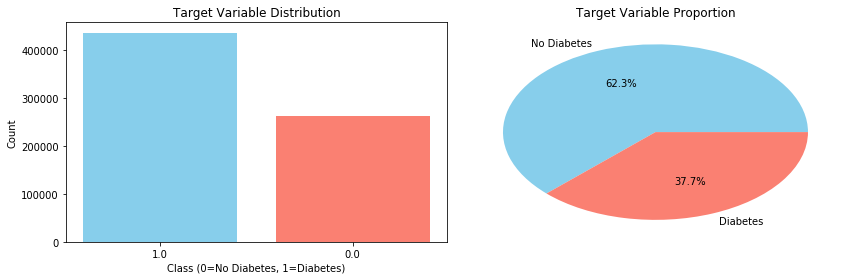


3. Data Overview
----------------------------------------

First 5 rows:
   id  age  alcohol_consumption_per_week  physical_activity_minutes_per_week  \
0   0   31                             1                                  45   
1   1   50                             2                                  73   
2   2   32                             3                                 158   
3   3   54                             3                                  77   
4   4   54                             1                                  55   

   diet_score  sleep_hours_per_day  screen_time_hours_per_day   bmi  \
0         7.7                  6.8                        6.1  33.4   
1         5.7                  6.5                        5.8  23.8   
2         8.5                  7.4                        9.1  24.1   
3         4.6                  7.0                        9.2  26.6   
4         5.7                  6.2                        5.1  28.8   

   waist_to_hip_ra

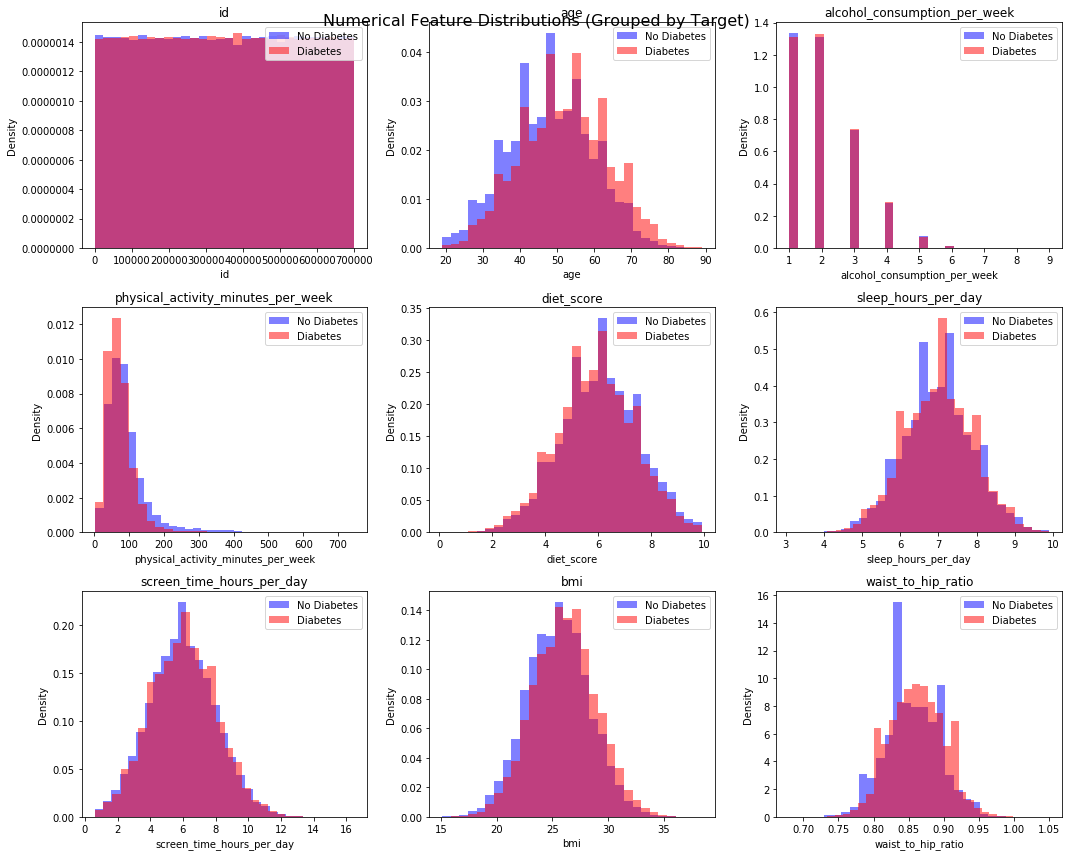


7. Outlier Detection
----------------------------------------
Feature Lower Bound Outlier %  Outlier Count Upper Bound
                                id  -349999.50     0.00%              0  1049998.50
                               age       18.00     0.14%           1013       82.00
      alcohol_consumption_per_week       -2.00     0.07%            509        6.00
physical_activity_minutes_per_week      -21.50     4.78%          33490      166.50
                        diet_score        2.00     0.29%           1997       10.00
               sleep_hours_per_day        4.60     0.88%           6152        9.40
         screen_time_hours_per_day        0.40     0.33%           2337       11.60
                               bmi       18.05     0.61%           4254       33.65
                waist_to_hip_ratio        0.75     0.88%           6159        0.96
                       systolic_bp       84.00     0.11%            775      148.00


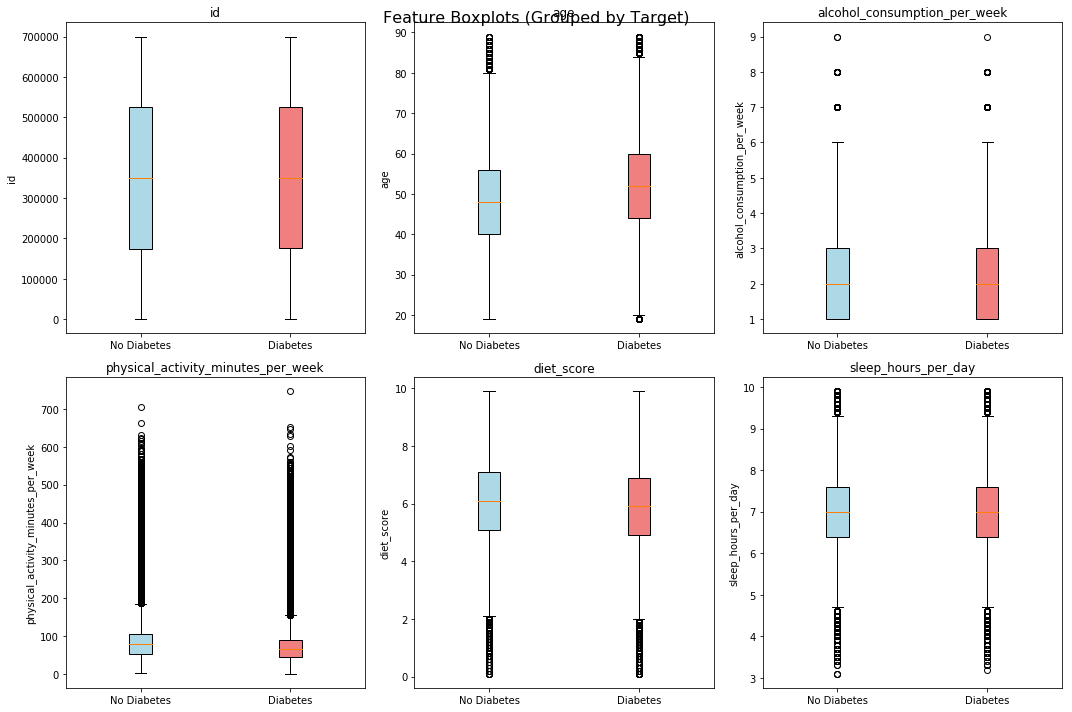


8. Feature Correlation Analysis
----------------------------------------

Top 10 features with highest positive correlation to target:
family_history_diabetes    0.211064
age                        0.161162
systolic_bp                0.107132
bmi                        0.105580
ldl_cholesterol            0.102771
triglycerides              0.090635
cholesterol_total          0.088112
waist_to_hip_ratio         0.081050
diastolic_bp               0.036271
hypertension_history       0.029979

Top 10 features with highest negative correlation to target:
hypertension_history                  0.029979
cardiovascular_history                0.024746
heart_rate                            0.023865
screen_time_hours_per_day             0.018213
sleep_hours_per_day                   0.003509
alcohol_consumption_per_week          0.002991
id                                   -0.000075
diet_score                           -0.050119
hdl_cholesterol                      -0.053231
physical_activity_m

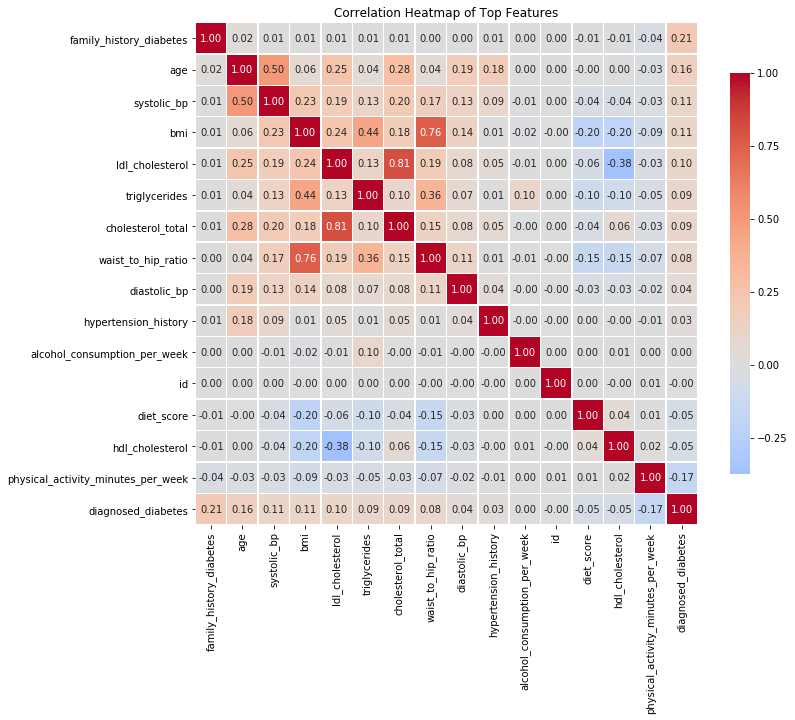


9. Categorical Feature Analysis
----------------------------------------

Feature 'gender' value distribution:
Female    363237
Male      333085
Other       3678
Name: gender, dtype: int64

Cross-tabulation with target (%):
diagnosed_diabetes    0.0    1.0
gender                          
Female              37.78  62.22
Male                37.57  62.43
Other               35.94  64.06


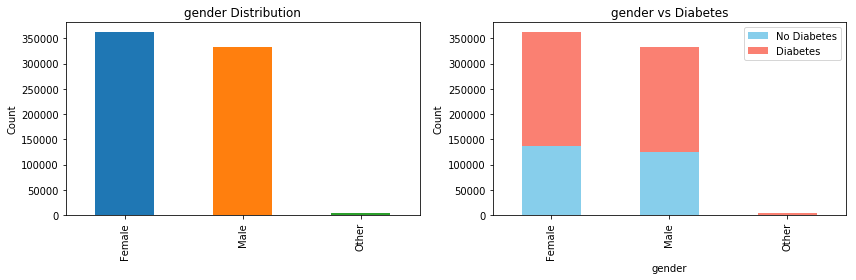


Feature 'ethnicity' value distribution:
White       386153
Hispanic    129984
Black       106301
Asian        60120
Other        17442
Name: ethnicity, dtype: int64

Cross-tabulation with target (%):
diagnosed_diabetes    0.0    1.0
ethnicity                       
Asian               37.15  62.85
Black               37.61  62.39
Hispanic            38.37  61.63
Other               36.41  63.59
White               37.59  62.41


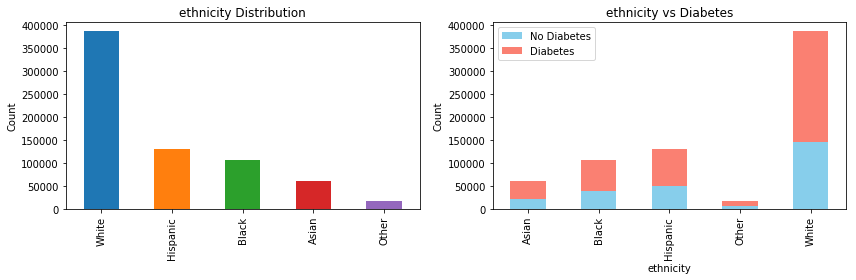


Feature 'education_level' value distribution:
Highschool      344145
Graduate        261268
Postgraduate     79642
No formal        14945
Name: education_level, dtype: int64

Cross-tabulation with target (%):
diagnosed_diabetes    0.0    1.0
education_level                 
Graduate            37.30  62.70
Highschool          37.85  62.15
No formal           36.39  63.61
Postgraduate        38.34  61.66


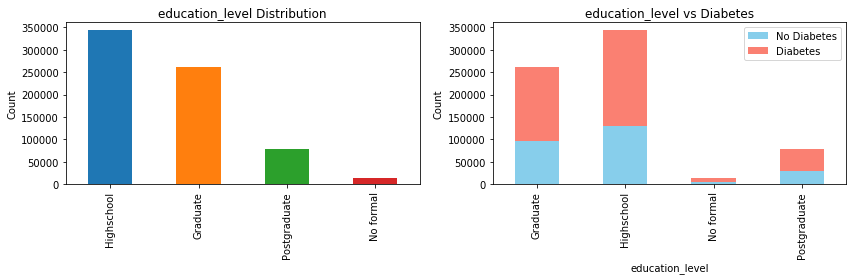


10. EDA Quick Summary
----------------------------------------

Dataset Overview:
- Training samples: 700,000
- Number of features: 26
- Target variable: diagnosed_diabetes
- Class distribution: 263,693 No Diabetes, 436,307 Diabetes
- Imbalance ratio: 1.655

Data Quality:
- Missing values: No
- Numerical features: 19
- Categorical features: 6

Key Findings:
- Top 3 features correlated with target: ['family_history_diabetes', 'age', 'systolic_bp']
- Correlation values: [0.211, 0.161, 0.107]

EDA Complete!


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Load data
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')
sample = pd.read_csv('../data/sample_submission.csv')

print("="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

# === 1. Basic Structure ===
print("\n1. Dataset Basic Information")
print("-" * 40)
print(f"Training set shape: {train.shape}")
print(f"Test set shape: {test.shape}")
print(f"\nTraining set columns: {train.columns.tolist()}")
print(f"\nData type summary:")
print(train.dtypes.value_counts())

# === 2. Target Variable Confirmation ===
print("\n" + "="*60)
print("2. Target Variable Confirmation")
print("-" * 40)
target_col = 'diagnosed_diabetes'

if target_col in train.columns:
    print(f"✓ Target column '{target_col}' exists")
    
    print(f"\nTarget distribution:")
    print(train[target_col].value_counts())
    print(f"\nTarget proportion:")
    print(train[target_col].value_counts(normalize=True) * 100)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    target_counts = train[target_col].value_counts()
    axes[0].bar(target_counts.index.astype(str), target_counts.values, 
                color=['skyblue', 'salmon'])
    axes[0].set_title('Target Variable Distribution')
    axes[0].set_xlabel('Class (0=No Diabetes, 1=Diabetes)')
    axes[0].set_ylabel('Count')
    
    axes[1].pie(target_counts.values, labels=['No Diabetes', 'Diabetes'], 
                autopct='%1.1f%%', colors=['skyblue', 'salmon'])
    axes[1].set_title('Target Variable Proportion')
    
    plt.tight_layout()
    plt.show()
else:
    print(f"✗ Target column '{target_col}' not found!")
    print(f"Available columns: {train.columns.tolist()}")
    for col in train.columns:
        if 'diabetes' in col.lower() or 'target' in col.lower():
            target_col = col
            print(f"Auto-detected target column: '{target_col}'")
            break

# === 3. Data Overview ===
print("\n" + "="*60)
print("3. Data Overview")
print("-" * 40)
print("\nFirst 5 rows:")
print(train.head())

print("\nStatistical summary:")
print(train.describe())

# === 4. Missing Values Check ===
print("\n" + "="*60)
print("4. Missing Values Check")
print("-" * 40)
missing = train.isnull().sum()
missing_percent = (missing / len(train)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing Percentage': missing_percent
})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)

if len(missing_df) > 0:
    print("Missing values found:")
    print(missing_df)
    
    plt.figure(figsize=(12, 6))
    sns.heatmap(train.isnull(), yticklabels=False, cbar=False, cmap='viridis')
    plt.title('Missing Values Heatmap')
    plt.show()
else:
    print("✓ No missing values!")

# === 5. Feature Type Analysis ===
print("\n" + "="*60)
print("5. Feature Type Analysis")
print("-" * 40)

numeric_cols = train.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols:
    numeric_cols.remove(target_col)

categorical_cols = train.select_dtypes(include=['object']).columns.tolist()

print(f"Numerical features ({len(numeric_cols)}):")
print(numeric_cols[:10])
if len(numeric_cols) > 10:
    print(f"... and {len(numeric_cols)-10} more")

print(f"\nCategorical features ({len(categorical_cols)}):")
print(categorical_cols)

# === 6. Numerical Feature Distribution ===
print("\n" + "="*60)
print("6. Numerical Feature Distribution Analysis")
print("-" * 40)

# Select first 9 numerical features for visualization
plot_features = numeric_cols[:min(9, len(numeric_cols))]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.ravel()

for idx, feature in enumerate(plot_features):
    axes[idx].hist(train[train[target_col]==0][feature].dropna(), 
                   bins=30, alpha=0.5, label='No Diabetes', color='blue', density=True)
    axes[idx].hist(train[train[target_col]==1][feature].dropna(), 
                   bins=30, alpha=0.5, label='Diabetes', color='red', density=True)
    axes[idx].set_title(f'{feature}')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Density')
    axes[idx].legend()

for idx in range(len(plot_features), 9):
    axes[idx].set_visible(False)

plt.suptitle('Numerical Feature Distributions (Grouped by Target)', fontsize=16)
plt.tight_layout()
plt.show()

# === 7. Outlier Detection ===
print("\n" + "="*60)
print("7. Outlier Detection")
print("-" * 40)

def detect_outliers(df, feature):
    """Detect outliers using IQR method"""
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

outlier_stats = []
for feature in numeric_cols[:10]:
    n_outliers, lower, upper = detect_outliers(train, feature)
    outlier_stats.append({
        'Feature': feature,
        'Outlier Count': n_outliers,
        'Outlier %': f"{n_outliers/len(train)*100:.2f}%",
        'Lower Bound': f"{lower:.2f}",
        'Upper Bound': f"{upper:.2f}"
    })

outlier_df = pd.DataFrame(outlier_stats)
print(outlier_df.to_string(index=False))

# Boxplot visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for idx, feature in enumerate(plot_features[:6]):
    data_to_plot = [train[train[target_col]==0][feature].dropna(),
                    train[train[target_col]==1][feature].dropna()]
    bp = axes[idx].boxplot(data_to_plot, labels=['No Diabetes', 'Diabetes'], patch_artist=True)
    
    bp['boxes'][0].set_facecolor('lightblue')
    bp['boxes'][1].set_facecolor('lightcoral')
    
    axes[idx].set_title(f'{feature}')
    axes[idx].set_ylabel(feature)

plt.suptitle('Feature Boxplots (Grouped by Target)', fontsize=16)
plt.tight_layout()
plt.show()

# === 8. Correlation Analysis ===
print("\n" + "="*60)
print("8. Feature Correlation Analysis")
print("-" * 40)

correlation = train[numeric_cols + [target_col]].corr()

target_correlation = correlation[target_col].drop(target_col).sort_values(ascending=False)

print("\nTop 10 features with highest positive correlation to target:")
print(target_correlation.head(10).to_string())

print("\nTop 10 features with highest negative correlation to target:")
print(target_correlation.tail(10).to_string())

top_features = target_correlation.head(10).index.tolist() + \
               target_correlation.tail(5).index.tolist() + \
               [target_col]
top_features = list(dict.fromkeys(top_features))

plt.figure(figsize=(12, 10))
sns.heatmap(train[top_features].corr(), annot=True, fmt='.2f', 
            cmap='coolwarm', center=0, square=True,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of Top Features')
plt.tight_layout()
plt.show()

# === 9. Categorical Feature Analysis ===
if len(categorical_cols) > 0:
    print("\n" + "="*60)
    print("9. Categorical Feature Analysis")
    print("-" * 40)
    
    for cat_col in categorical_cols[:3]:
        print(f"\nFeature '{cat_col}' value distribution:")
        print(train[cat_col].value_counts())
        
        if target_col in train.columns:
            print(f"\nCross-tabulation with target (%):")
            crosstab = pd.crosstab(train[cat_col], train[target_col], normalize='index') * 100
            print(crosstab.round(2))
            
            # Visualization
            fig, axes = plt.subplots(1, 2, figsize=(12, 4))
            
            train[cat_col].value_counts().plot(kind='bar', ax=axes[0])
            axes[0].set_title(f'{cat_col} Distribution')
            axes[0].set_ylabel('Count')
            
            pd.crosstab(train[cat_col], train[target_col]).plot(
                kind='bar', stacked=True, ax=axes[1], 
                color=['skyblue', 'salmon']
            )
            axes[1].set_title(f'{cat_col} vs Diabetes')
            axes[1].set_ylabel('Count')
            axes[1].legend(['No Diabetes', 'Diabetes'])
            
            plt.tight_layout()
            plt.show()

# === 10. Quick Summary ===
print("\n" + "="*60)
print("10. EDA Quick Summary")
print("-" * 40)

print(f"""
Dataset Overview:
- Training samples: {len(train):,}
- Number of features: {len(train.columns)}
- Target variable: {target_col}
- Class distribution: {target_counts[0]:,} No Diabetes, {target_counts[1]:,} Diabetes
- Imbalance ratio: {target_counts[1]/target_counts[0]:.3f}

Data Quality:
- Missing values: {'Yes' if len(missing_df) > 0 else 'No'}
- Numerical features: {len(numeric_cols)}
- Categorical features: {len(categorical_cols)}

Key Findings:
- Top 3 features correlated with target: {target_correlation.head(3).index.tolist()}
- Correlation values: {target_correlation.head(3).values.round(3).tolist()}
""")

print("="*60)
print("EDA Complete!")
